# Credit Card Fraud Detection
### Machine Learning Project

This project aims to detect fraudulent credit card transactions using machine learning models.  
The dataset contains transaction information such as merchant, amount, location, and customer attributes.

## 1. Import Libraries
We start by importing the Python libraries required for data processing and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset
We load the credit card fraud dataset containing over one million transaction records.

In [3]:
train = pd.read_csv("fraudTrain.csv")

print(train.shape)

train.head()

(1080685, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2.703186e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495.0,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1.325376e+09,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,6.304233e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149.0,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1.325376e+09,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,3.885949e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154.0,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1.325376e+09,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3.534094e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939.0,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1.325376e+09,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,3.755342e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99.0,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1.325376e+09,38.674999,-78.632459,0.0


## 3. Explore the Dataset (EDA)
We inspect the structure of the dataset and understand the distribution of features.

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080685 entries, 0 to 1080684
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1080685 non-null  int64  
 1   trans_date_trans_time  1080685 non-null  object 
 2   cc_num                 1080684 non-null  float64
 3   merchant               1080684 non-null  object 
 4   category               1080684 non-null  object 
 5   amt                    1080684 non-null  float64
 6   first                  1080684 non-null  object 
 7   last                   1080684 non-null  object 
 8   gender                 1080684 non-null  object 
 9   street                 1080684 non-null  object 
 10  city                   1080684 non-null  object 
 11  state                  1080684 non-null  object 
 12  zip                    1080684 non-null  float64
 13  lat                    1080684 non-null  float64
 14  long              

In [5]:
train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.080685e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06,1.080684e+06
mean,5.403420e+05,4.174708e+17,7.033038e+01,4.880917e+04,3.853370e+01,-9.022938e+01,8.904131e+04,1.345460e+09,3.853371e+01,-9.022954e+01,5.812060e-03
std,3.119670e+05,1.309232e+18,1.595502e+02,2.689918e+04,5.076948e+00,1.375866e+01,3.022902e+05,1.053262e+07,5.111225e+00,1.377090e+01,7.601503e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,2.701710e+05,1.800400e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.336924e+09,3.473001e+01,-9.689909e+01,0.000000e+00
50%,5.403420e+05,3.520550e+15,4.746000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.345386e+09,3.936294e+01,-8.744278e+01,0.000000e+00
75%,8.105130e+05,4.642255e+15,8.309000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.354851e+09,4.195660e+01,-8.023418e+01,0.000000e+00
max,1.080684e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.364141e+09,6.751027e+01,-6.695090e+01,1.000000e+00


### Fraud Distribution
We check how many transactions are fraudulent versus legitimate.
Fraud detection datasets are usually highly imbalanced.

In [6]:
train["is_fraud"].value_counts()

is_fraud
0.0    1074403
1.0       6281
Name: count, dtype: int64

In [7]:
train["is_fraud"].value_counts(normalize=True)

is_fraud
0.0    0.994188
1.0    0.005812
Name: proportion, dtype: float64

## visualize the imbalance

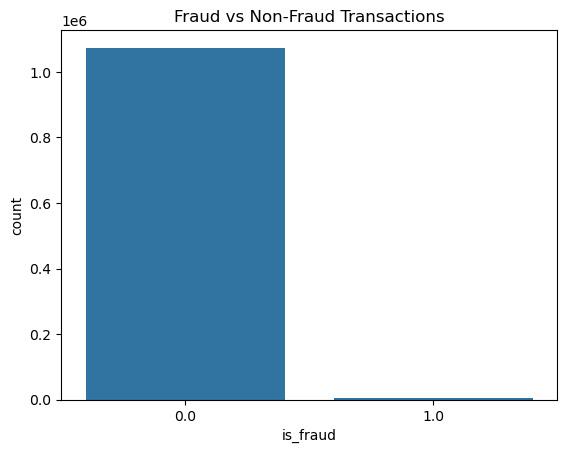

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="is_fraud", data=train)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

## 4. Data Cleaning and Feature Selection
Some columns contain personal or identifier information that is not useful for
prediction. These columns are removed before training the model.

In [9]:
train = train.drop(columns=[
"Unnamed: 0",
"cc_num",
"first",
"last",
"street",
"city",
"state",
"zip",
"dob",
"trans_num",
"trans_date_trans_time"
])

train.head()

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495.0,"Psychologist, counselling",1.325376e+09,36.011293,-82.048315,0.0
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149.0,Special educational needs teacher,1.325376e+09,49.159047,-118.186462,0.0
2,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154.0,Nature conservation officer,1.325376e+09,43.150704,-112.154481,0.0
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939.0,Patent attorney,1.325376e+09,47.034331,-112.561071,0.0
4,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99.0,Dance movement psychotherapist,1.325376e+09,38.674999,-78.632459,0.0


### Handling Missing Values

The dataset contains a small number of missing values.  
Rows containing missing values are removed before training the model to ensure compatibility with machine learning algorithms.

In [13]:
train = train.dropna()

train.isnull().sum()

merchant      0
category      0
amt           0
gender        0
lat           0
long          0
city_pop      0
job           0
unix_time     0
merch_lat     0
merch_long    0
is_fraud      0
dtype: int64

## 5. Encoding Categorical Variables
Machine learning models cannot process text directly.  
We convert categorical features into numerical values using Label Encoding.

In [14]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

train["merchant"] = encoder.fit_transform(train["merchant"])
train["category"] = encoder.fit_transform(train["category"])
train["gender"] = encoder.fit_transform(train["gender"])
train["job"] = encoder.fit_transform(train["job"])

train.head()

,merchant,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud
0,514,8,4.97,0,36.0788,-81.1781,3495.0,370,1.325376e+09,36.011293,-82.048315,0.0
1,241,4,107.23,0,48.8878,-118.2105,149.0,428,1.325376e+09,49.159047,-118.186462,0.0
2,390,0,220.11,1,42.1808,-112.2620,4154.0,307,1.325376e+09,43.150704,-112.154481,0.0
3,360,2,45.00,1,46.2306,-112.1138,1939.0,328,1.325376e+09,47.034331,-112.561071,0.0
4,297,9,41.96,1,38.4207,-79.4629,99.0,116,1.325376e+09,38.674999,-78.632459,0.0


## 6. Train-Test Split
We separate the dataset into features (X) and the target variable (y).  
The target variable is `is_fraud`, which indicates whether a transaction is fraudulent.

In [15]:
X = train.drop("is_fraud", axis=1)
y = train["is_fraud"]

print(X.shape)
print(y.shape)

(1080684, 11)
(1080684,)


### Splitting the Data
We split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(864547, 11)
(216137, 11)


## 7. Model Training

We train a Random Forest classifier to detect fraudulent transactions.
Random Forest performs well on structured tabular datasets and can handle
nonlinear relationships between features.

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

## Model Evaluation

In [18]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[214790     91]
 [   409    847]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    214881
         1.0       0.90      0.67      0.77      1256

    accuracy                           1.00    216137
   macro avg       0.95      0.84      0.89    216137
weighted avg       1.00      1.00      1.00    216137



## Confusion Matrix Visualization

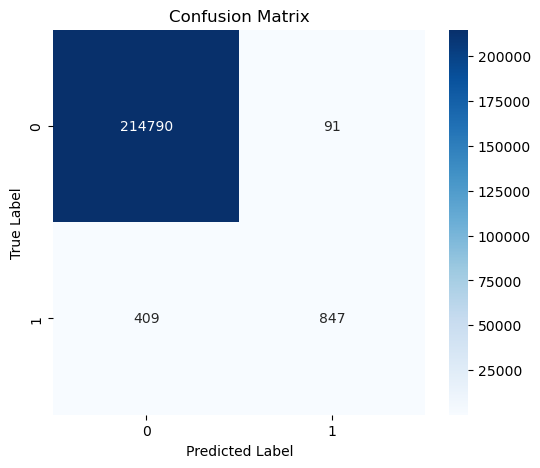

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

## Feature Importance

In [20]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

amt           0.690752
category      0.118317
unix_time     0.036852
city_pop      0.024058
merch_long    0.021765
job           0.021658
merch_lat     0.021257
merchant      0.020652
long          0.019939
lat           0.019862
gender        0.004888
dtype: float64

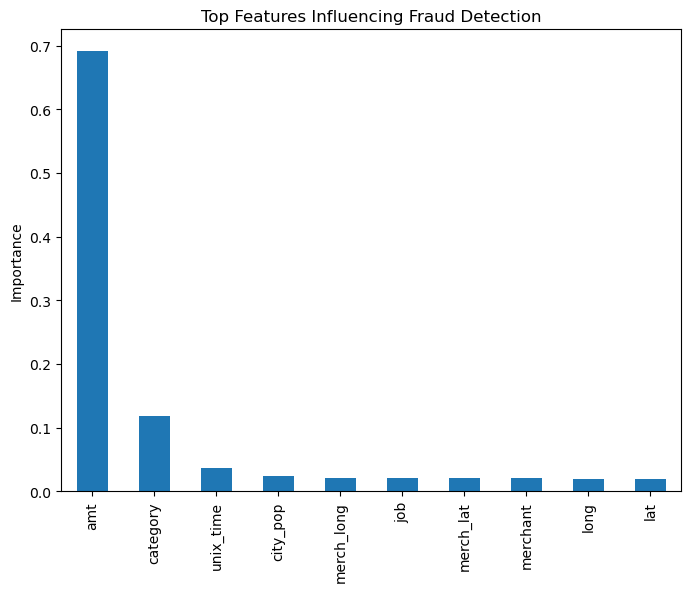

In [21]:
plt.figure(figsize=(8,6))
feature_importance.head(10).plot(kind="bar")

plt.title("Top Features Influencing Fraud Detection")
plt.ylabel("Importance")
plt.show()

### Model Performance Analysis

The Random Forest classifier achieved strong performance in detecting fraudulent transactions.

However, due to the highly imbalanced nature of fraud datasets, accuracy alone is not an informative metric. Instead, recall for the fraud class is particularly important, as it measures the model's ability to correctly detect fraudulent transactions.

The baseline model achieved a fraud recall of approximately 0.67, meaning that it successfully detected 67% of fraudulent transactions.

## Improving Fraud Recall with Threshold Adjustment

In [22]:
y_prob = model.predict_proba(X_test)[:,1]

threshold = 0.30

y_pred_adjusted = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_adjusted))
print(classification_report(y_test, y_pred_adjusted)) 

[[214587    294]
 [   268    988]]
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    214881
         1.0       0.77      0.79      0.78      1256

    accuracy                           1.00    216137
   macro avg       0.88      0.89      0.89    216137
weighted avg       1.00      1.00      1.00    216137



### Threshold Optimization

Fraud detection datasets are highly imbalanced.  
Instead of using the default classification threshold (0.5), the fraud probability threshold was reduced to 0.30.

This adjustment increased fraud recall from 0.67 to 0.79, allowing the model to detect significantly more fraudulent transactions.

While this slightly reduced precision, improving recall is often more important in fraud detection systems because missed fraud cases can be costly.

## Handling Class Imbalance with SMOTE

Fraud detection datasets are highly imbalanced, with far fewer fraudulent transactions than legitimate ones.

To help the model learn fraud patterns better, we apply SMOTE (Synthetic Minority Over-sampling Technique), which generates synthetic fraud samples to balance the dataset.

In [23]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(1719044, 11)
is_fraud
0.0    859522
1.0    859522
Name: count, dtype: int64


## Training Model with SMOTE Data

In [25]:
from sklearn.ensemble import RandomForestClassifier

model_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_smote.fit(X_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1, random_state=42)

## Evaluate the SMOTE Model

In [26]:
y_pred_smote = model_smote.predict(X_test)

print(confusion_matrix(y_test, y_pred_smote))
print(classification_report(y_test, y_pred_smote))

[[213508   1373]
 [   260    996]]
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00    214881
         1.0       0.42      0.79      0.55      1256

    accuracy                           0.99    216137
   macro avg       0.71      0.89      0.77    216137
weighted avg       1.00      0.99      0.99    216137



### Model Performance Analysis

The Random Forest classifier achieved strong performance in detecting fraudulent transactions.

However, due to the highly imbalanced nature of fraud datasets, accuracy alone is not an informative metric. Instead, recall for the fraud class is particularly important, as it measures the model's ability to correctly detect fraudulent transactions.

The baseline model achieved a fraud recall of approximately 0.67, meaning that it successfully detected 67% of fraudulent transactions.

## Conclusion

This project implemented a machine learning pipeline to detect fraudulent credit card transactions.

The workflow included exploratory data analysis, data cleaning, categorical feature encoding, handling class imbalance, and training a Random Forest classifier.

Different strategies were evaluated to improve fraud detection performance, including threshold optimization and SMOTE oversampling.

The best-performing approach involved adjusting the classification threshold, which increased fraud recall to approximately 0.79 while maintaining a reasonable precision level.

Future improvements could include testing additional models such as Gradient Boosting or XGBoost, as well as incorporating temporal and behavioral transaction features.